In [1]:
%load_ext autoreload
%autoreload 2
import os, sys
sys.path.append("../../")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from tqdm import tqdm

from utils import SpikeTester

plt.rc('xtick',labelsize=25)
plt.rc('ytick',labelsize=25)
# mpl.rcParams['figure.dpi'] = 200 
mpl.rcParams['figure.figsize'] = (12, 9) 
mpl.rcParams['axes.titlesize'] = 30
mpl.rcParams['axes.labelsize'] = 25
mpl.rcParams['legend.fontsize'] = 20
# mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#003052", "#C71818", "#18C7C7", "#70C718", "#7018C7"])
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#6ba0a6", "#d8584e", "#c09651", "#f8c08a", "#8e4f39"])

In [2]:
radar_config = {
    "n_rx": 1,
    "fb" : 60e9,
    "B" : 2.0e9,
    "n_chirps": 64,
    "n_samples": 128,
    "t_chirp": 6.4e-5,
    "IQ": True,
    "noise_std": 0.001,
    "target_snr_db": 20
}

In [3]:
targets = [
    {
        "range":1.6,
        "velocity": 0.0,
        "angle": np.deg2rad(0)
    },
    {
        "range":4.0,
        "velocity": 0,
        "angle": np.deg2rad(0)
    },
    {
        "range": 7.0,
        "velocity": 0,
        "angle": np.deg2rad(0)
    }
    # {
    #     "range": 0.8,
    #     "velocity": 0,
    #     "angle": np.deg2rad(0)
    # }
]

In [4]:
spike_tester = SpikeTester(radar_config, targets, random_start=False)

In [5]:
spike_tester.run_test(spike_tester.fmcw.get_freq_from_range(0.1))

/home/chistefano/code/tue/frequency_adaptive_oscillator/notebooks/spiking_tests/../../src/py_network/resonate_net.py:41: RuntimeWarning: divide by zero encountered in divide
  self.periods = ((2 * np.pi) / (self.t_res * self.ws)).astype(int)
/home/chistefano/code/tue/frequency_adaptive_oscillator/notebooks/spiking_tests/../../src/py_network/resonate_net.py:41: RuntimeWarning: invalid value encountered in cast
  self.periods = ((2 * np.pi) / (self.t_res * self.ws)).astype(int)


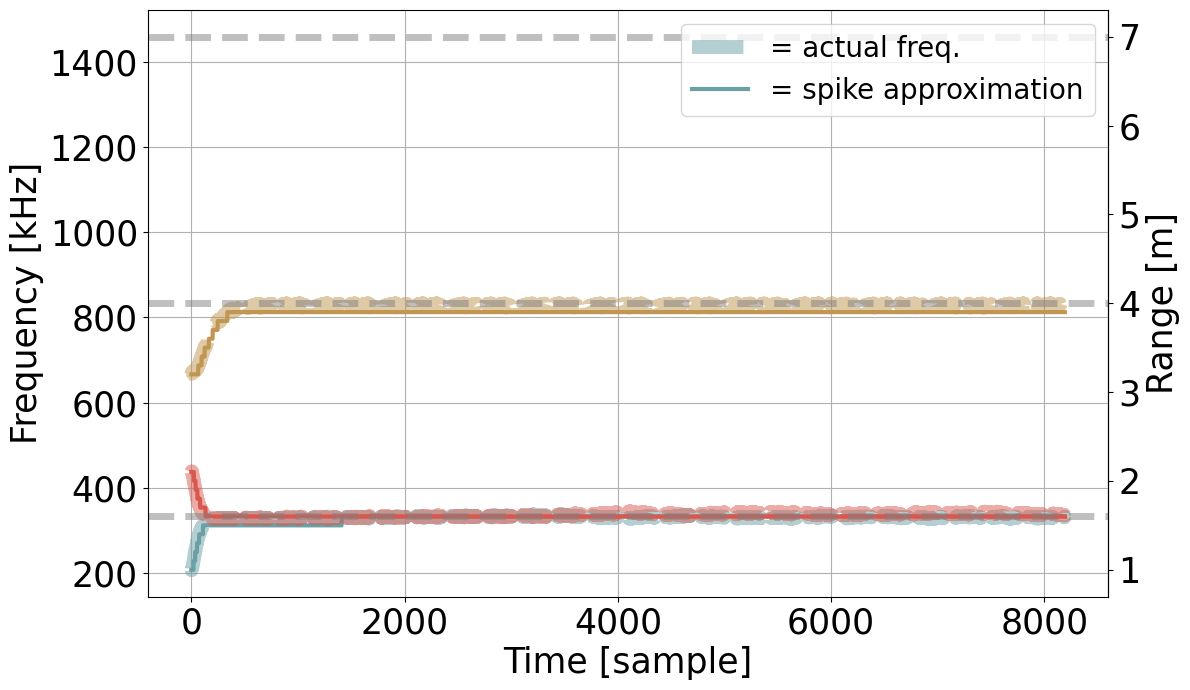

In [8]:
fig, ax = plt.subplots(1, figsize=(12, 7))

actual_ws_hz = (spike_tester.ws_hist / (2 * np.pi)) 
actual_ws_khz = np.mod(actual_ws_hz, spike_tester.fmcw.get_freq_from_range(spike_tester.fmcw.max_range))* 1e-3
spike_ws_hz = (spike_tester.res_net.integrate_spikes() / (2 * np.pi)) 
spike_ws_khz = np.mod(spike_ws_hz.squeeze(), spike_tester.fmcw.get_freq_from_range(spike_tester.fmcw.max_range))* 1e-3

for i in range(len(targets)):
        ax.plot(actual_ws_khz[:, i], 
                # label="actual frequency",
                linewidth=10,
                c=f"C{i}",
                linestyle="--",
                alpha=0.5)
        ax.plot(spike_ws_khz[:, i], 
                # label="spike approximation",
                linewidth=3, 
                c=f"C{i}")
        
for t in targets:
        ax.axhline(spike_tester.fmcw.get_freq_from_range(t['range'] * 1e-3),
        linestyle='--',
        c='grey',
        alpha=0.5,
        linewidth=5)

ax.legend(['= actual freq.','= spike approximation'])

ax.set_xlabel("Time [sample]")
ax.set_ylabel("Frequency [kHz]")
ax.grid()

secy = ax.secondary_yaxis('right', functions=(lambda x: spike_tester.fmcw.get_range_from_freq(x * 1e3, negative=True), 
                                            lambda x: spike_tester.fmcw.get_freq_from_range(x) * 1e-3))
secy.set_ylabel("Range [m]")

plt.tight_layout()
plt.savefig("../paper_figures/spike_approximation_example_10cm.pdf", bbox_inches="tight")

In [9]:
print(spike_tester.get_number_of_spikes())

18.0


In [10]:
spike_tester.fmcw.get_range_from_freq(200 * 1e3)

np.float64(0.96)

In [11]:
spike_tester.fmcw.get_freq_from_range(2.5) * 1e-3

520.8333333333334

In [12]:
spike_tester = SpikeTester(radar_config, targets)

In [13]:
threshold_low = spike_tester.fmcw.get_freq_from_range(0.01) #/ (2 * np.pi)
threshold_high = spike_tester.fmcw.get_freq_from_range(0.5) #/ (2 * np.pi)
n_tests = 100
thresholds_to_test = np.linspace(threshold_low, threshold_high, n_tests, endpoint=True)

In [14]:
errors = np.zeros((n_tests,))
sparsity = np.zeros((n_tests,))
n_spikes = np.zeros((n_tests,))
trials_per_thresh = 100

for i in tqdm(range(thresholds_to_test.size)):
    for i in range(trials_per_thresh):
        spike_tester.run_test(thresholds_to_test[i], frames_to_use=1)
        errors[i] += spike_tester.measure_error()
        sparsity[i] += spike_tester.measure_sparsity()
        n_spikes[i] += spike_tester.get_number_of_spikes()

errors /= trials_per_thresh
sparsity /= trials_per_thresh
n_spikes /= trials_per_thresh
    

  0%|          | 0/100 [00:00<?, ?it/s]

/home/chistefano/code/tue/frequency_adaptive_oscillator/notebooks/spiking_tests/../../src/py_network/resonate_net.py:41: RuntimeWarning: divide by zero encountered in divide
  self.periods = ((2 * np.pi) / (self.t_res * self.ws)).astype(int)
/home/chistefano/code/tue/frequency_adaptive_oscillator/notebooks/spiking_tests/../../src/py_network/resonate_net.py:41: RuntimeWarning: invalid value encountered in cast
  self.periods = ((2 * np.pi) / (self.t_res * self.ws)).astype(int)
100%|██████████| 100/100 [00:30<00:00,  3.32it/s]


In [15]:
fft_size = spike_tester.fmcw.generate_data_snr().size

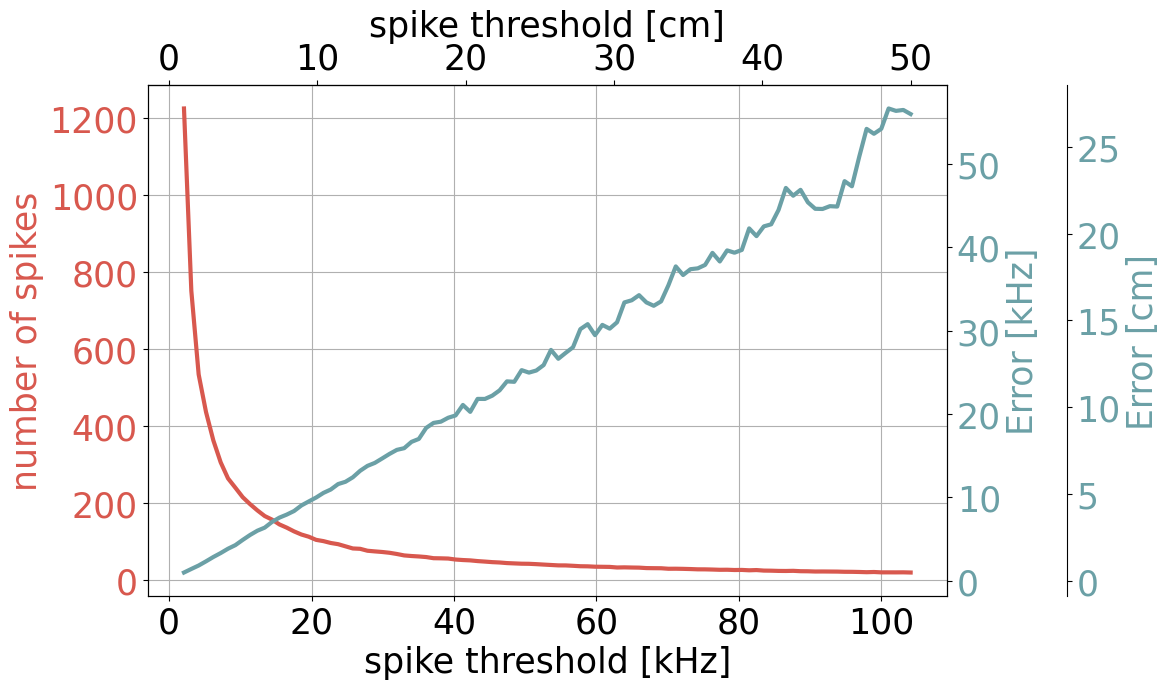

In [16]:
fig, ax = plt.subplots(1, figsize=(12, 7))
thresholds_to_test_meters = spike_tester.fmcw.get_range_from_freq(thresholds_to_test)
thresholds_to_test_khz = thresholds_to_test * 1e-3

ax.plot(thresholds_to_test_khz, n_spikes, c="C1", label="", linewidth=3)
ax.ticklabel_format(style="plain")
# ax.legend(loc="upper left")
ax.set_xlabel("spike threshold [kHz]")
ax.set_ylabel("number of spikes", color="C1")
ax.tick_params(axis='y', labelcolor="C1")
ax.grid()

# right axis, error meters + Khz
ax2 = ax.twinx()
ax2.set_ylabel("Error [kHz]", color="C0")
errors_khz = errors * 1e-3
ax2.plot(thresholds_to_test_khz, errors_khz,c="C0", label="error", linewidth=3)
# ax2.legend(loc="upper right")
ax2.tick_params(axis='y', labelcolor="C0")

#top axis, threshold in meter
secx = ax.secondary_xaxis('top', functions=(lambda x: spike_tester.fmcw.get_range_from_freq(x * 1e3, negative=True) * 1e2, 
                                            lambda x: spike_tester.fmcw.get_freq_from_range(x * 1e-2) * 1e-3))
secx.set_xlabel("spike threshold [cm]")

secay = ax2.secondary_yaxis(
    1.15,
    functions=(
        lambda x: spike_tester.fmcw.get_range_from_freq(x * 1e3, negative=True) * 1e2,  # kHz → m
        lambda x: spike_tester.fmcw.get_freq_from_range(x * 1e-2) * 1e-3   # m → kHz (inverse)
    )
)
secay.set_ylabel("Error [cm]", color="C0")
secay.tick_params(axis='y', labelcolor="C0")

plt.tight_layout()
plt.savefig("../paper_figures/spike_statistics.pdf", bbox_inches="tight")